## Prep and Load Df

In [116]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [47]:
full = pd.read_csv("/Users/emmiekao/Downloads/datasci112_final.csv")

In [49]:
full.head()

,FIPS,County,"Fast-food restaurants/1,000 population",Median household income,% Population with low access to store,% Adults with Obesity,% Adults with Diabetes
0,6001,Alameda,0.827156,108971.0,8.083675,23.5,9.1
1,6003,Alpine,2.680965,87570.0,56.969242,29.9,9.9
2,6005,Amador,0.573809,68159.0,0.174187,29.4,9.0
3,6007,Butte,0.737976,62982.0,19.113434,31.7,9.5
4,6009,Calaveras,0.604647,68298.0,14.736117,30.1,8.7


unfortunately, there are some NaN values that won't work with the chosen regressions.

In [95]:
clean = full.dropna()

## Prep Models and Eval

In [52]:
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error

In [101]:
def get_linreg(x, y):
    x = np.asarray(x).reshape(-1, 1)
    y = np.asarray(y).reshape(-1, 1)
    
    pipeline = make_pipeline(
          #StandardScaler(),
          LinearRegression())
    scores = cross_val_score(
        pipeline,
        X=x,
        y=y,
        scoring="neg_mean_squared_error",
        cv=4)
    return -scores.mean()

In [134]:
def get_knn(x, y, k):
    x = np.asarray(x).reshape(-1, 1)
    y = np.asarray(y).reshape(-1, 1)
    
    pipeline = make_pipeline(
          StandardScaler(),
          KNeighborsRegressor()
    )
    ks = range(1,k)
    scores = GridSearchCV(pipeline, 
                       param_grid={'kneighborsregressor__n_neighbors': ks},
                       cv=4, 
                       scoring='neg_mean_squared_error',
                  return_train_score=True)
    scores.fit(x, y)
    train_mse = -scores.cv_results_['mean_train_score']
    test_mse  = -scores.cv_results_['mean_test_score']
    
    train_rmse = np.sqrt(train_mse)
    test_rmse  = np.sqrt(test_mse)
    
    plt.figure()
    plt.plot(ks, train_rmse, marker='o', label='Train RMSE')
    plt.plot(ks, test_rmse,  marker='o', label='Test RMSE')
    plt.xlabel('k (n_neighbors)')
    plt.ylabel('RMSE')
    plt.xticks(ks)
    plt.legend()
    plt.show()
    print(scores.best_params_)

## Food Deserts (Fast Food)

### Obesity

In [142]:
x = clean["Fast-food restaurants/1,000 population"]
y = clean["% Adults with Obesity"]

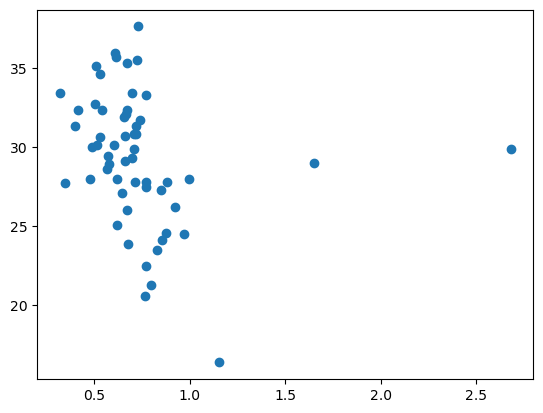

In [144]:
plt.scatter(x,y);

In [146]:
get_linreg(x,y)

22.813532673235596

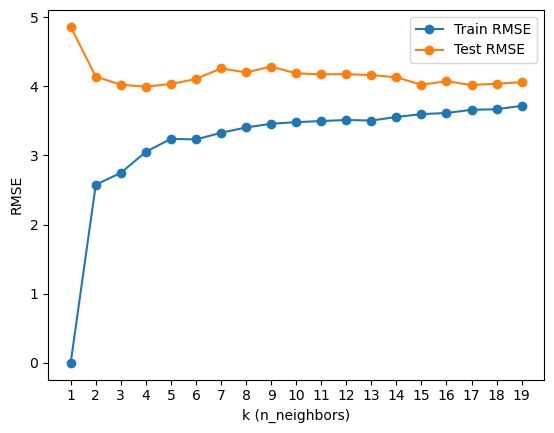

{'kneighborsregressor__n_neighbors': 4}


In [148]:
get_knn(x,y,20)

### Diabetes

In [150]:
x = clean["Fast-food restaurants/1,000 population"]
y = clean["% Adults with Diabetes"]

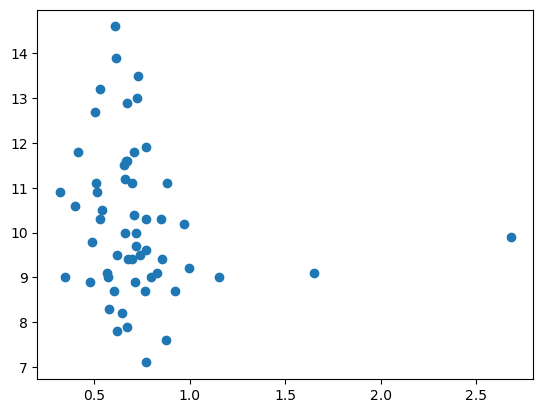

In [152]:
plt.scatter(x,y);

In [154]:
get_linreg(x,y)

2.8164040625932194

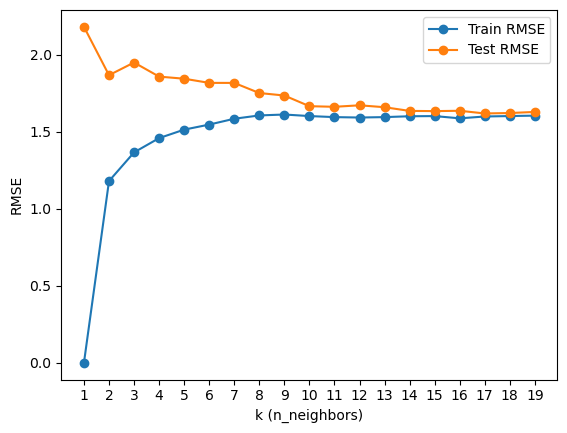

{'kneighborsregressor__n_neighbors': 17}


In [156]:
get_knn(x,y,20)

## Household Income

### Obesity

In [159]:
x = clean["Median household income"]
y = clean["% Adults with Obesity"]

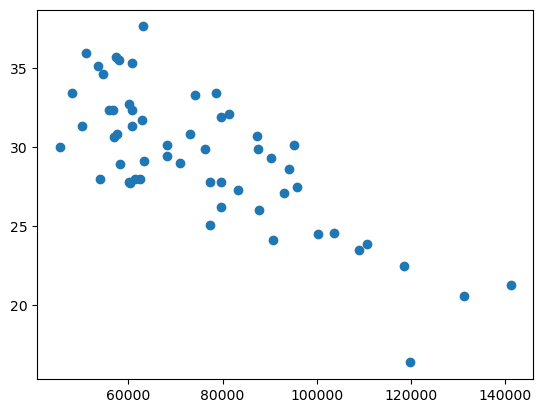

In [161]:
plt.scatter(x,y);

In [163]:
get_linreg(x,y)

7.385294768703481

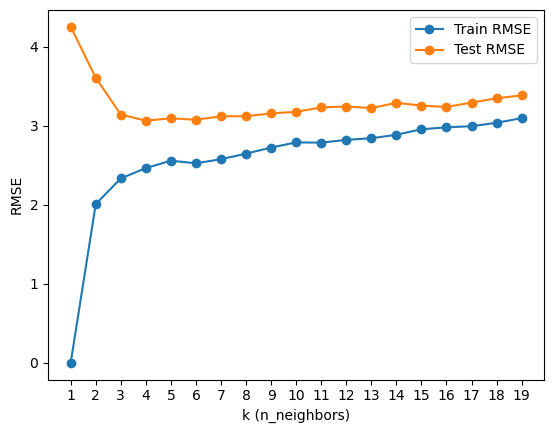

{'kneighborsregressor__n_neighbors': 4}


In [165]:
get_knn(x,y,20)

### Diabetes

In [167]:
x = clean["Median household income"]
y = clean["% Adults with Diabetes"]

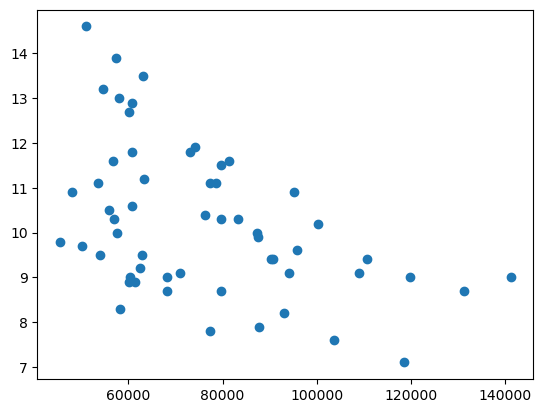

In [169]:
plt.scatter(x,y);

In [171]:
get_linreg(x,y)

2.327802051794001

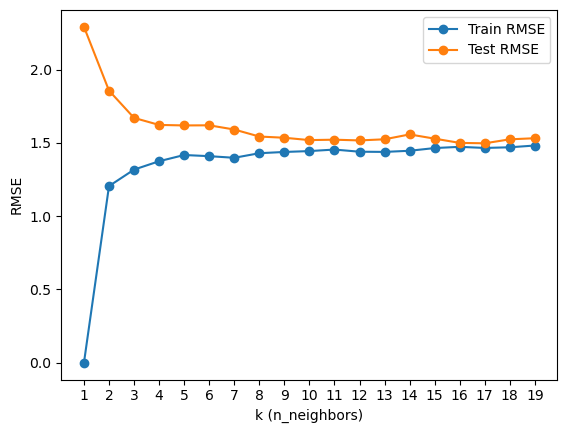

{'kneighborsregressor__n_neighbors': 17}


In [173]:
get_knn(x,y,20)

## Access to Store (Food Swamps)

### Obesity

In [176]:
x = clean["% Population with low access to store"]
y = clean["% Adults with Obesity"]

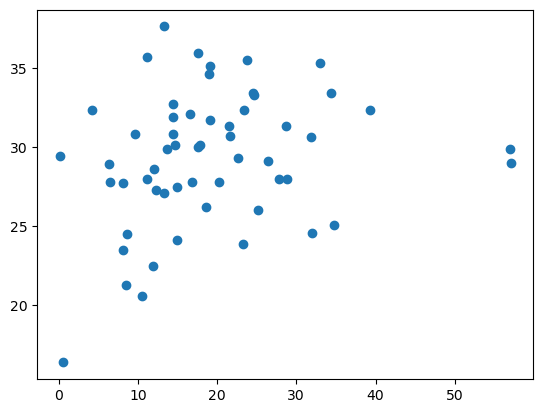

In [178]:
plt.scatter(x,y);

In [180]:
get_linreg(x,y)

19.81860649529383

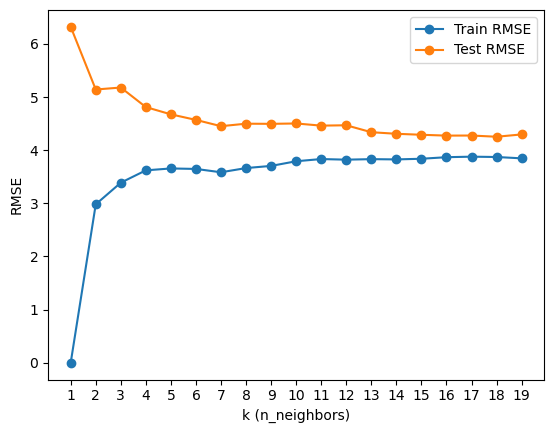

{'kneighborsregressor__n_neighbors': 18}


In [182]:
get_knn(x,y,20)

### Diabetes

In [185]:
x = clean["% Population with low access to store"]
y = clean["% Adults with Diabetes"]

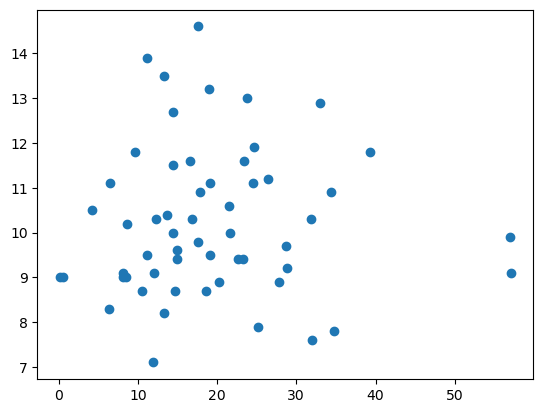

In [187]:
plt.scatter(x,y);

In [189]:
get_linreg(x,y)

2.8173323983848446

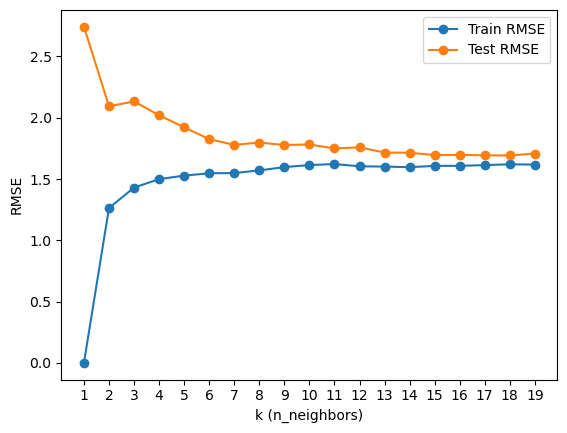

{'kneighborsregressor__n_neighbors': 18}


In [191]:
get_knn(x,y,20)